# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Muhamad Rafli Kamal]
- **Email:** [mraflikamal28@gmail.com]
- **ID Dicoding:** [m-rafli-kamal]

## Menentukan Pertanyaan Bisnis


- **Pertanyaan 1:** Bagaimana tren rata-rata tingkat polusi udara (berdasarkan konsentrasi PM2.5) di stasiun Changping dari tahun 2013 hingga 2017, dan pada bulan apa biasanya tingkat polusi memburuk?
- **Pertanyaan 2:** Bagaimana korelasi antara kondisi cuaca, khususnya suhu (TEMP) dan curah hujan (RAIN), terhadap tingkat konsentrasi PM2.5?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style untuk visualisasi
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset
df_changping = pd.read_csv('data/PRSA_Data_Changping_20130301-20170228.csv')
df_changping.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


**Insight:**
- Dataset yang digunakan dalam proyek ini adalah Air Quality Dataset pada wilayah Changping

### Assessing Data

In [3]:
print("Info Dataset:")
df_changping.info()

print("\nMissing Values:")
print(df_changping.isna().sum())

print("\nJumlah Duplikasi: ", df_changping.duplicated().sum())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

Missing Values:
No            0
year          0
month

**Insight:**
- Terdapat *missing values* pada kolom krusial seperti PM2.5, TEMP, dan RAIN.
- Tipe data tanggal/waktu (year, month, day, hour) masih terpisah, perlu digabung menjadi satu kolom `datetime` untuk mempermudah analisis *time-series*.
- Tidak ada data duplikat.

### Cleaning Data

In [4]:
# Membuat kolom datetime
df_changping['datetime'] = pd.to_datetime(df_changping[['year', 'month', 'day', 'hour']])

# Mengisi missing values dengan forward fill lalu backward fill untuk sisanya
df_changping.fillna(method='ffill', inplace=True)
df_changping.fillna(method='bfill', inplace=True)

# Memastikan tidak ada lagi missing values
print("Sisa Missing Values:\n", df_changping.isna().sum()[['PM2.5', 'TEMP', 'RAIN']])

# Menyimpan data yang sudah bersih untuk dashboard
df_changping.to_csv('dashboard/main_data.csv', index=False)

Sisa Missing Values:
 PM2.5    0
TEMP     0
RAIN     0
dtype: int64


C:\Users\muham\AppData\Local\Temp\ipykernel_23456\3073262311.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_changping.fillna(method='ffill', inplace=True)
C:\Users\muham\AppData\Local\Temp\ipykernel_23456\3073262311.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_changping.fillna(method='bfill', inplace=True)


**Insight:**
- Kolom `datetime` berhasil dibuat dengan menggabungkan kolom `year`, `month`, `day`, dan `hour`, sehingga analisis *time-series* menjadi lebih mudah dilakukan.
- *Missing values* pada seluruh kolom berhasil diisi menggunakan metode *forward fill* (`ffill`) dilanjutkan *backward fill* (`bfill`), sehingga tidak ada lagi data yang hilang dan dataset siap untuk dianalisis.

## Exploratory Data Analysis (EDA)

### Explore Parameter Kualitas Udara & Cuaca

In [5]:
# Agregasi tren bulanan PM2.5
monthly_pm25 = df_changping.groupby(['year', 'month'])['PM2.5'].mean().reset_index()

# Melihat statistik deskriptif dari parameter penting
df_changping[['PM2.5', 'TEMP', 'RAIN']].describe()

,PM2.5,TEMP,RAIN
count,35064.000000,35064.000000,35064.000000
mean,71.119444,13.670841,0.060295
std,72.424333,11.368584,0.752361
min,2.000000,-16.600000,0.000000
25%,18.000000,3.400000,0.000000
50%,47.000000,14.600000,0.000000
75%,100.000000,23.300000,0.000000
max,882.000000,41.400000,52.100000


**Insight:**
- Rata-rata konsentrasi PM2.5 adalah **71.12 µg/m³** dengan nilai maksimum mencapai **882 µg/m³**, jauh melampaui ambang batas WHO (25 µg/m³). Standar deviasi yang besar (72.42) mengindikasikan variasi tingkat polusi yang sangat tinggi antar waktu.
- Suhu rata-rata adalah **13.67°C** dengan rentang antara -16.6°C hingga 41.4°C, mencerminkan iklim empat musim di Beijing. Curah hujan (RAIN) sangat rendah — nilai median dan Q1, Q3 semuanya 0 — artinya hujan hanya terjadi sesekali.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Bulanan Rata-Rata PM2.5

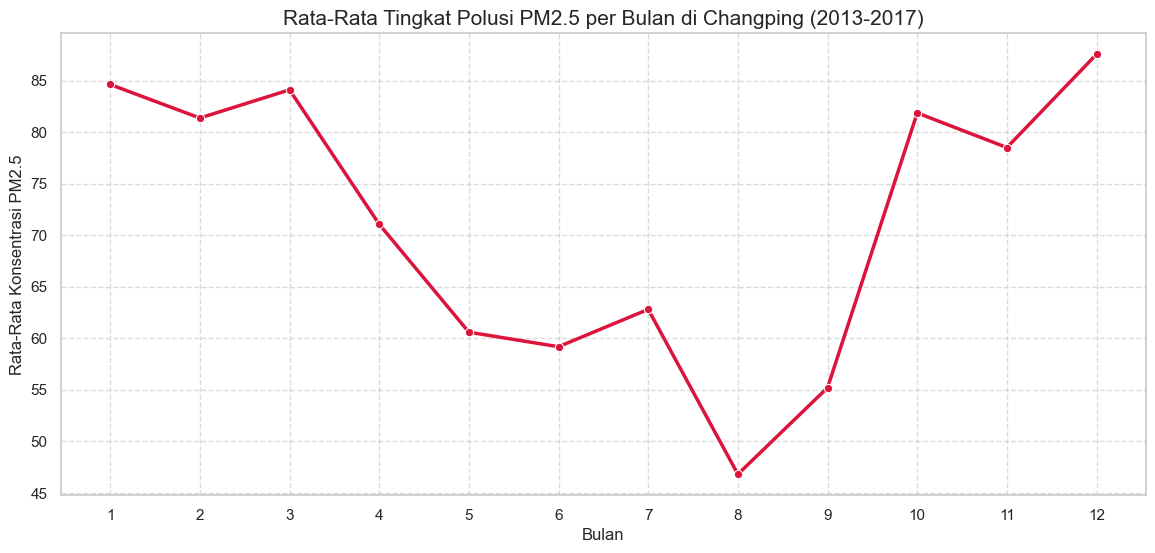

In [6]:
plt.figure(figsize=(14, 6))
# Menghitung rata-rata PM2.5 per bulan secara keseluruhan
monthly_avg = df_changping.groupby('month')['PM2.5'].mean()

sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='crimson', linewidth=2.5)
plt.title('Rata-Rata Tingkat Polusi PM2.5 per Bulan di Changping (2013-2017)', fontsize=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-Rata Konsentrasi PM2.5', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Korelasi Suhu dan Hujan terhadap PM2.5

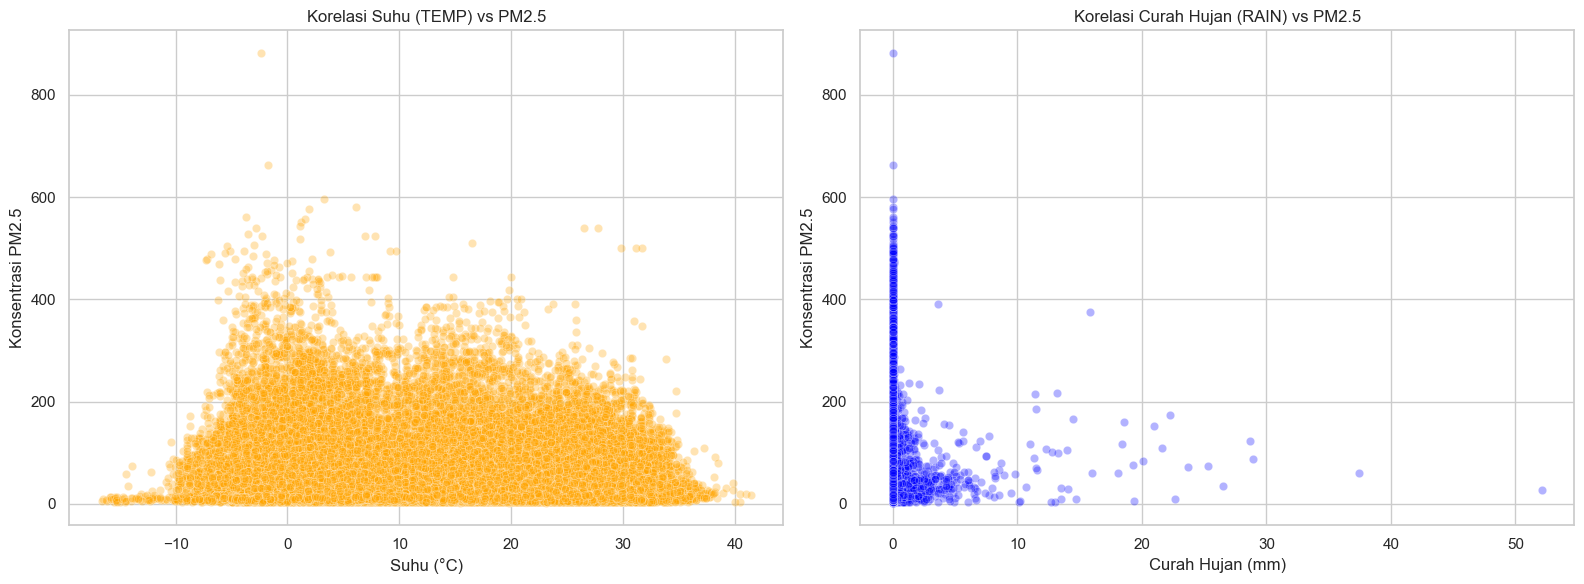

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot Suhu vs PM2.5
sns.scatterplot(data=df_changping, x='TEMP', y='PM2.5', alpha=0.3, ax=ax[0], color='orange')
ax[0].set_title('Korelasi Suhu (TEMP) vs PM2.5')
ax[0].set_xlabel('Suhu (°C)')
ax[0].set_ylabel('Konsentrasi PM2.5')

# Scatter plot Hujan vs PM2.5
sns.scatterplot(data=df_changping, x='RAIN', y='PM2.5', alpha=0.3, ax=ax[1], color='blue')
ax[1].set_title('Korelasi Curah Hujan (RAIN) vs PM2.5')
ax[1].set_xlabel('Curah Hujan (mm)')
ax[1].set_ylabel('Konsentrasi PM2.5')

plt.tight_layout()
plt.show()

**Insight:**
- Polusi udara (PM2.5) di Changping memiliki pola musiman, di mana polusi cenderung memburuk pada musim dingin (November hingga Februari) dan membaik pada musim panas (Mei hingga Agustus).
- Terdapat korelasi negatif antara suhu dan hujan terhadap PM2.5. Saat suhu tinggi dan curah hujan meningkat, tingkat polusi cenderung lebih rendah karena proses pencucian partikel oleh hujan dan sirkulasi udara yang lebih baik di musim panas.

## Analisis Lanjutan Clustering dengan Teknik Binning
Menggunakan teknik **Binning** untuk mengelompokkan (clustering) data PM2.5 ke dalam kategori Kualitas Udara berdasarkan standar indeks:
- **Baik**: 0 - 35
- **Sedang**: 35.1 - 75
- **Tidak Sehat**: 75.1 - 150
- **Berbahaya**: > 150

Tujuan teknik ini adalah mempermudah stakeholder dalam memahami seberapa sering warga Changping terpapar udara dalam kategori bahaya tanpa harus melihat angka numerik mentah.

C:\Users\muham\AppData\Local\Temp\ipykernel_23456\2428164148.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kategori_counts, x='Kategori', y='Jumlah_Jam', palette=colors)


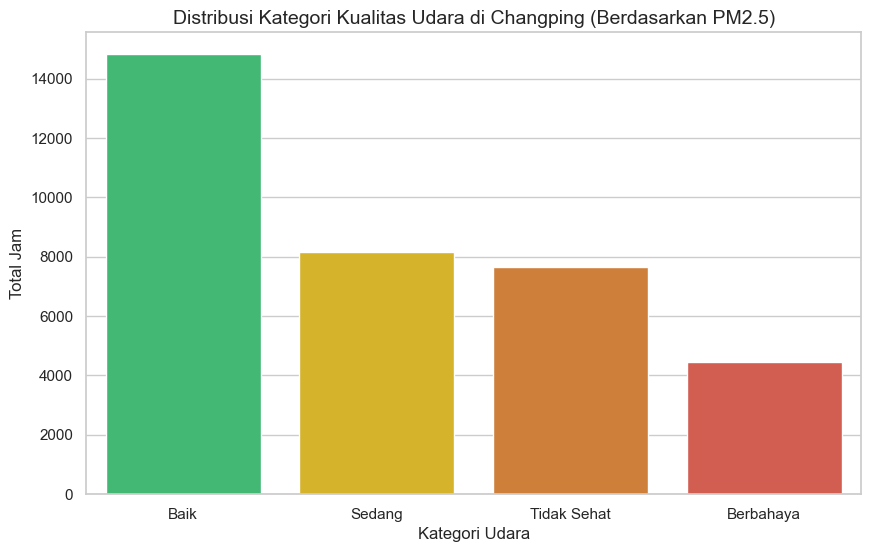

In [8]:
# Membuat bins dan labels untuk kategori kualitas udara
bins = [0, 35, 75, 150, df_changping['PM2.5'].max()]
labels = ['Baik', 'Sedang', 'Tidak Sehat', 'Berbahaya']

# Menerapkan binning
df_changping['Kategori_Udara'] = pd.cut(df_changping['PM2.5'], bins=bins, labels=labels, include_lowest=True)

# Visualisasi Hasil Clustering (Binning)
kategori_counts = df_changping['Kategori_Udara'].value_counts().reset_index()
kategori_counts.columns = ['Kategori', 'Jumlah_Jam']

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
sns.barplot(data=kategori_counts, x='Kategori', y='Jumlah_Jam', palette=colors)
plt.title('Distribusi Kategori Kualitas Udara di Changping (Berdasarkan PM2.5)', fontsize=14)
plt.xlabel('Kategori Udara')
plt.ylabel('Total Jam')
plt.show()

## Conclusion


- **Conclusion Pertanyaan 1:** Tren rata-rata polusi PM2.5 di Changping menunjukkan pola fluktuasi musiman yang sangat jelas. Tingkat polusi udara menyentuh titik terburuk pada bulan-bulan akhir hingga awal tahun (Desember - Februari), yang identik dengan musim dingin. Sebaliknya, udara cenderung lebih bersih di pertengahan tahun.
- **Conclusion Pertanyaan 2:** Kondisi cuaca berpengaruh signifikan terhadap polusi. Suhu yang lebih hangat dan curah hujan yang lebih tinggi berkorelasi dengan menurunnya angka PM2.5. Hujan bertindak sebagai "pencuci" alami partikel polusi di udara.
- **Conclusion Analisis Lanjutan (Clustering/Binning):** Dari hasil pengelompokan manual, meskipun sebagian besar waktu kualitas udara di Changping masuk kategori 'Baik' dan 'Sedang', masih terdapat frekuensi yang sangat tinggi di mana udara masuk pada level 'Tidak Sehat' hingga 'Berbahaya', yang membutuhkan intervensi kebijakan lebih lanjut terutama di musim dingin.